# Grating from TMatrixC

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import treams

In [3]:
k0 = 2 * np.pi / 700
materials = [treams.Material(-16.5 + 1j), treams.Material()]
lmax = mmax = 3
radii = [65, 55]
positions = [[-40, -50, 0], [40, 50, 0]]
lattice_z = treams.Lattice(300)
lattice_x = treams.Lattice(300, "x")
kz = 0.005

In [4]:
sphere = treams.TMatrix.sphere(lmax, k0, radii[0], materials)
chain = sphere.latticeinteraction.solve(lattice_z, kz)
bmax = 1.1 * lattice_z.reciprocal
cwb = treams.CylindricalWaveBasis.diffr_orders(kz, mmax, lattice_z, bmax)
kzs = np.unique(cwb.kz)
chain_tmc = treams.TMatrixC.from_array(chain, cwb)
cylinder = treams.TMatrixC.cylinder(kzs, mmax, k0, radii[1], materials)

/home/runner/work/treams/treams/src/treams/_operators.py:532: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = cw.to_sw(
/home/runner/work/treams/treams/src/treams/_operators.py:829: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = sw.periodic_to_cw(


In [5]:
cluster = treams.TMatrixC.cluster(
    [chain_tmc, cylinder], positions
).latticeinteraction.solve(lattice_x, 0)
inc = treams.plane_wave(
    [0, np.sqrt(k0 ** 2 - kz ** 2), kz],
    [np.sqrt(0.5), -np.sqrt(0.5)],
    k0=chain.k0,
    material=chain.material,
)
sca = cluster @ inc.expand(cluster.basis)

/home/runner/work/treams/treams/src/treams/_operators.py:607: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = pw.to_cw(


In [6]:
x = 0
y = np.linspace(-150, 150, 16)
z = np.linspace(-150, 150, 16)
yy, zz = np.meshgrid(y, z, indexing="ij")
xx = np.full_like(yy, x)
grid = np.stack((xx, yy, zz), axis=-1)

In [7]:
ex = np.zeros_like(xx)
valid = cluster.valid_points(grid, radii)
vals = []
for i, r in enumerate(grid[valid]):
    cwb = treams.CylindricalWaveBasis.default(kzs, 1, positions=[r])
    field = sca.expandlattice(basis=cwb).efield(r)
    vals.append(np.real(inc.efield(r)[0] + field[0]))
ex[valid] = vals
ex[~valid] = np.nan

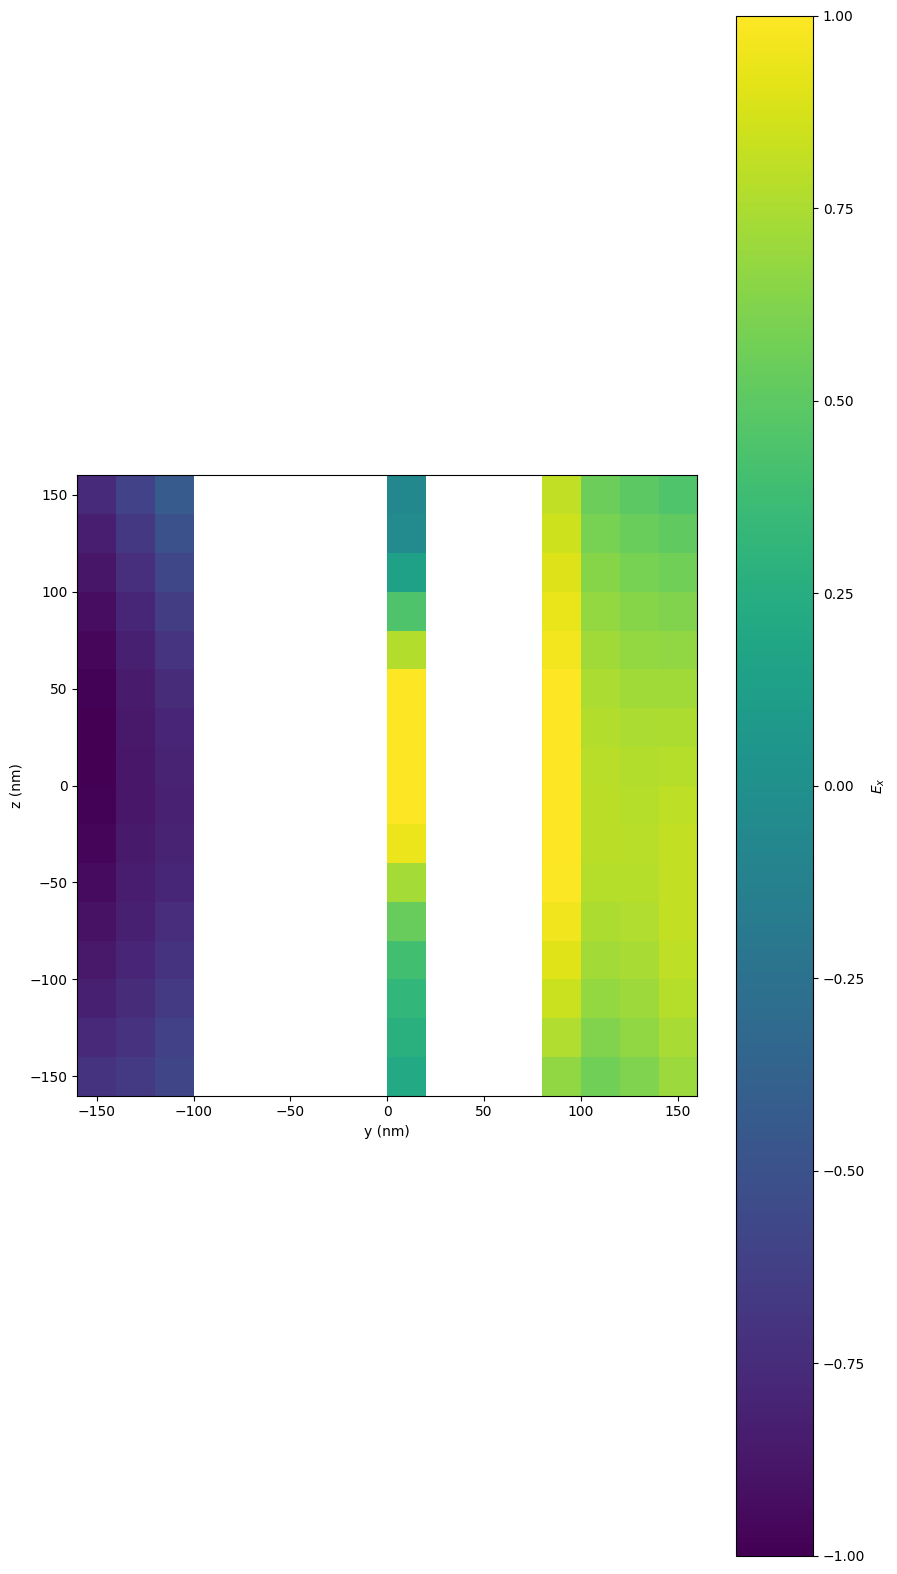

In [8]:
fig, ax = plt.subplots(figsize=(10, 20))
pcm = ax.pcolormesh(
    yy, zz, ex, shading="nearest", vmin=-1, vmax=1,
)
cb = plt.colorbar(pcm)
cb.set_label("$E_x$")
ax.set_xlabel("y (nm)")
ax.set_ylabel("z (nm)")
ax.set_aspect("equal")
fig.show()